In [ ]:
import numpy as np
from numpy.linalg import norm
import math, random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import initializers

# Absorption probability inside a sphere

In [ ]:
import numpy as np
import scipy.special as sp

class pr_absorb(object):
    def __init__(self,**kwargs):
        self.d = kwargs.get("d", 3)
        self.nu = (self.d-2)/2

    def __call__(self, cr2):
        return np.power(np.sqrt(cr2),self.nu)/(np.power(2,self.nu)*sp.gamma(self.nu+1)*sp.iv(self.nu,np.sqrt(cr2)))

# Shortest distance

In [31]:
#spatial funcs for WoS

def closestPoint(v, s):
    u = s[1] - s[0]
    rate = max(0, min(u.dot(v - s[0])/u.dot(u), 1))
    return (s[0] + rate*(s[1] - s[0]))

def shortestDistance(v, segments):
    r = float("inf")
    for s in segments:
        u = closestPoint(v, s)
        if norm(v - u) < r:
            r = norm(v - u)
    return r

$\begin{cases}\Delta u = cu & \Omega\\ u = e^{-\sqrt{c}x} + e^{\sqrt{c}y} &\partial\Omega\end{cases}$

In [ ]:
p = pr_absorb(d=2)
c = .5
def pathGenerator(v, segments, g, eps = 0.001, maxSteps = 16, maxR = 10, p = p):
    x0 = v
    path = []
    absorbed = 1
    for step in range(0, maxSteps): 
        path.append(x0)
        r = min([shortestDistance(x0, segments), maxR])
        absorbed *= 1 if (p(c*r*r)>=np.random.uniform(0, 1, 1)) else 0
        if r < eps: 
            return path, g(x0)*absorbed
        theta = random.uniform(0, 2*math.pi)
        x0 = x0 + np.array([r * math.cos(theta), r * math.sin(theta)])
    return [], 0

# Domain and boundary condition

In [33]:
# set up the problem
segments = [np.array([[-1, -1], [-1, 1]]), np.array([[-1, -1], [1, -1]]), np.array([[1, -1], [1, 1]]), np.array([[-1, 1], [1, 1]])]

#v = np.array([0, 0])
def boundary(v):
    return np.exp(np.sqrt(c)*v[0])+np.exp(np.sqrt(c)*v[1])

# Sample generator

In [34]:
#####evenly distributed start places
#target = []
#width = range(1, 220)
#height = range(1, 220)
#for i in width:
#    for j in height:
#        target.append(np.array([i/110 - 1, j/110 - 1]))

#print(len(target))

###### pure random start places
# target = np.random.rand(40000, 2)
# target = 2* target - 1

#####QMC start places
import scipy.stats as stats
qmcGenerator = stats.qmc.Sobol(d=2)
target = qmcGenerator.random(n=40000)
target = 2* target - 1

/opt/anaconda3/envs/Python31014/lib/python3.10/site-packages/scipy/stats/_qmc.py:958: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)


In [ ]:
paths = []
boundaries = []
maxPath = 0;
for v in target:
    p, b = pathGenerator(v, segments, boundary)
    if len(p) != 0:
        paths.append(p)
        boundaries.append(b)
        if len(p) > maxPath:
            maxPath = len(p)


[array([-0.35770188,  0.36609231]), array([-0.5580986 , -0.23530615]), array([-0.433012  , -0.65913417]), array([-0.58579273, -0.35442519]), array([-0.17336362, -0.31608606]), array([-0.39583438, -0.96280473]), array([-0.41099541, -0.99676988]), array([-0.41104443, -0.99354013]), array([-0.40864216, -0.99953671])]


In [36]:
paths1 = np.zeros((len(paths), maxPath, 2))
for i in range(len(paths)):
    path = paths[i]
    npath = np.array(path)
    if len(path) < maxPath:
        npath = np.concatenate((npath, np.ones((maxPath - len(path), 2)) * np.array(path[len(path) - 1])))

    paths1[i] = npath

print(paths1.shape)

(33502, 16, 2)


In [37]:
paths1 = paths1.reshape(-1, maxPath, 2).astype("float32")
boundary1 = np.array(boundaries).astype("float32")

In [38]:
class NN(keras.Model):
    def __init__(self, units):
        super(NN, self).__init__()
        self.layer1 = keras.layers.Dense(units[0])
        self.layer2 = keras.layers.Dense(units[1])
        self.layer3 = keras.layers.Dense(units[2])
        self.outputs = layers.Dense(3)

    def call(self, input_tensor, training):
        x = self.layer1(input_tensor)
        x = tf.nn.relu(x)
        x = self.layer2(x)
        x = tf.nn.relu(x)
        x = self.layer3(x)
        x = tf.nn.relu(x)
        x = self.outputs(x)
        #print(x.shape)
        return x

In [39]:
class Ysolver(keras.Model):
    # set y as a trainable variable, initialized randomly
    def __init__(self, layer):
        super(Ysolver, self).__init__()
        self.model = NN(layer)

        #self.y = tf.Variable(np.random.uniform(low=-1, high=1, size=[1, 1]),trainable = True, dtype ="float32")

    def call(self, path, training, batch):
        #print(path.shape)
        y_pred = self.model(path[:, 0], training)[:, 0]
        #print(y_pred.shape)
        for i in range(len(path[0]) - 1): ###input path should be (-1, 2) shaped nparray, no len()
            #y = self.Ymodel(path[:, i], training)
            #print(y.shape)
            #z_input = tf.concat([path[:, i],y], 1)
            z = self.model(path[:, i], training)[:, 1:3] #obtain gradients for steps
            diff = path[:, i + 1] - path[:, i]
            #print(diff.shape)
            add = z[:, 0]*diff[:, 0] + z[:, 1]*diff[:, 1] #accumulating
            #print(add.shape)
            y_pred += add

        return y_pred

In [40]:
class NNsolver(keras.Model):
    def __init__(self, paths, boundary):
        super(NNsolver, self).__init__()
        self.paths = paths
        self.boundary = np.array(boundary)
        self.model = Ysolver([32, 64, 128])
        self.optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=3e-4 , epsilon=1e-8)

    def loss_fn(self, y_pred, y):
        delta = y_pred - y
        loss = tf.reduce_mean(tf.square(delta))
        return loss

    def train_step(self, cur_path, training, batch_size):           
        return self.model(cur_path, training, batch_size)

    def train(self, batch_size): 
        training_history = []
        for i in range((len(self.paths) - 1)//batch_size + 1):
            batch = batch_size
            if (i + 1) * batch_size > len(paths):
                batch = len(paths) - i * batch_size
            cur_path = self.paths[i*batch_size: i*batch_size + batch]
            cur_bound = self.boundary[i*batch_size: i*batch_size + batch]
                
            with tf.GradientTape() as tape:
                y_pred = self.train_step(cur_path, training = True, batch_size=batch)
                loss = self.loss_fn(y_pred, cur_bound)

            training_vars = self.model.trainable_variables 
            grad = tape.gradient(loss, training_vars)
            #print(grad)
            #print("----------------------------------------------------")
            self.optimizer.apply_gradients(zip(grad, training_vars))
            #print(self.model.Ymodel.trainable_variables)
            training_history.append(loss)

        return training_history

    def train_epoch(self, epoch, batch_size):
        for i in range(epoch):
            cur_history = self.train(batch_size)
            print("epoch: " + str(i) + " loss: "+ str(np.mean(np.array(cur_history))))


In [41]:
training = NNsolver(paths1, boundary1)
training.train_epoch(50, 1024)

epoch: 0 loss: 4.7278395
epoch: 1 loss: 2.4759035
epoch: 2 loss: 0.6720726
epoch: 3 loss: 0.43933883
epoch: 4 loss: 0.40991312
epoch: 5 loss: 0.39084232
epoch: 6 loss: 0.3732289
epoch: 7 loss: 0.35664627
epoch: 8 loss: 0.34109402
epoch: 9 loss: 0.32686707
epoch: 10 loss: 0.31426328
epoch: 11 loss: 0.30341566
epoch: 12 loss: 0.2944008
epoch: 13 loss: 0.2876401
epoch: 14 loss: 0.28310063
epoch: 15 loss: 0.2802939
epoch: 16 loss: 0.2787003
epoch: 17 loss: 0.27783808
epoch: 18 loss: 0.27735585
epoch: 19 loss: 0.27706823
epoch: 20 loss: 0.2768804
epoch: 21 loss: 0.27675152
epoch: 22 loss: 0.2766654
epoch: 23 loss: 0.27659896
epoch: 24 loss: 0.27654743
epoch: 25 loss: 0.27649683
epoch: 26 loss: 0.27645177
epoch: 27 loss: 0.27641073
epoch: 28 loss: 0.27637523
epoch: 29 loss: 0.2763486
epoch: 30 loss: 0.27632248
epoch: 31 loss: 0.2763018
epoch: 32 loss: 0.27628186
epoch: 33 loss: 0.2762663
epoch: 34 loss: 0.27625293
epoch: 35 loss: 0.27623656
epoch: 36 loss: 0.2762254
epoch: 37 loss: 0.2762117

In [42]:
width = range(101)
height = range(101)

X = []
Y = []
Z = []
for i in width:
    for j in height:
        X.append(i/50 - 1)
        Y.append(j/50 - 1)
        Z.append(training.model.model(np.array([i/50 - 1 ,j/50 - 1]).reshape([1, 2]).astype("float32")))

X = np.array(X).reshape(101, 101)
Y = np.array(Y).reshape(101, 101)



In [43]:
Z2 = np.array(Z)[:, :, 0].reshape(101, 101)

0.004714052733200413 0.011982791354132034


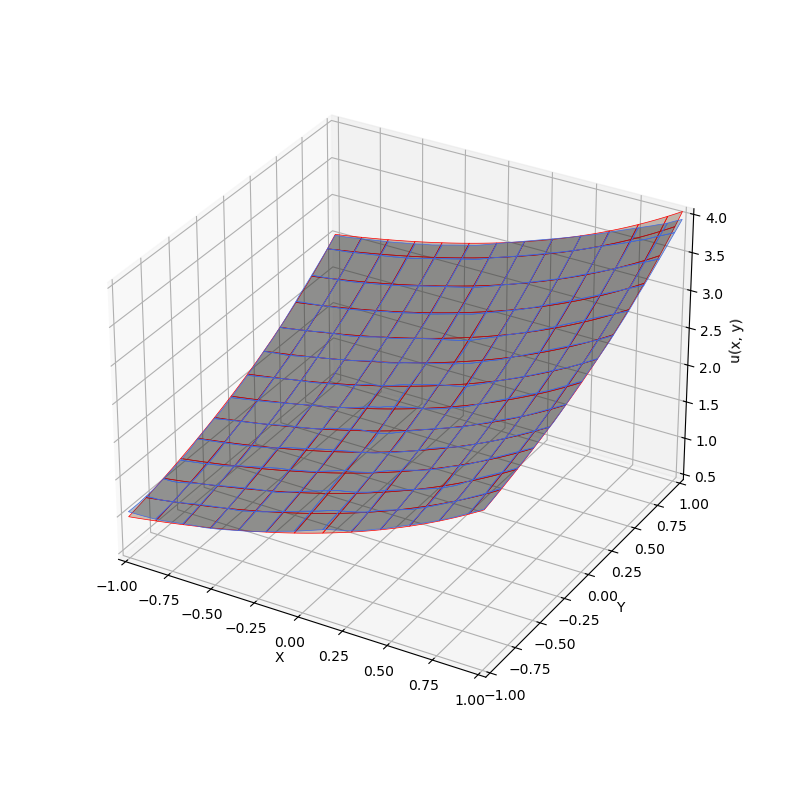

In [44]:
Z1 = np.exp(np.sqrt(c)*X)+np.exp(np.sqrt(c)*Y)

import matplotlib.pyplot as plt
ax = plt.figure(figsize = (8, 8)).add_subplot(projection='3d')

# Plot the 3D surface
ax.plot_surface(X, Y, Z2, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
ax.plot_surface(X, Y, Z1, edgecolor='red', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)

ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(0.5, 4),
       xlabel='X', ylabel='Y', zlabel='u(x, y)')

ax.set_box_aspect(None, zoom=0.85)
# ax.set_title("Fig3: WoSNN with randomly distributed start places for 2D Laplace", y=-0.01)
#plt.show()
plt.tight_layout();

plt.savefig('WoSNNMC2Dlaplace_c.png', bbox_inches='tight')
print(np.power((Z1-Z2),2).sum()/np.power(Z1,2).sum()*100, np.abs(Z1-Z2).sum()/(101*101))

0.4544980507993452 0.06763042415099375


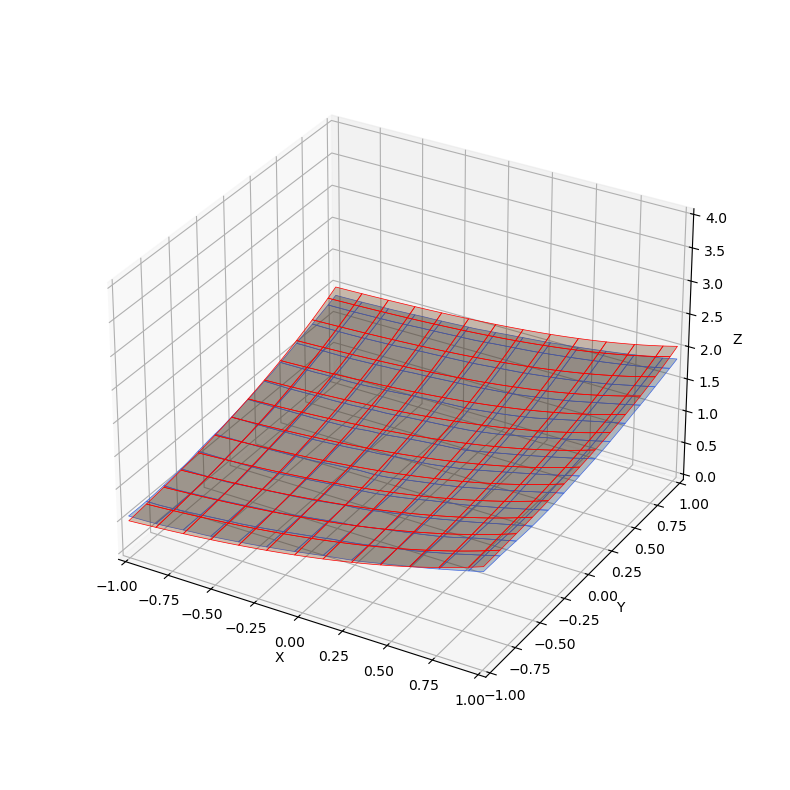

In [45]:
Z3 = np.linalg.norm(np.array(Z)[:, :, 1:3].reshape(-1, 2), axis = 1).reshape(101, 101)
Z1 = np.sqrt(c*np.exp(2*np.sqrt(c)*X)+c*np.exp(2*np.sqrt(c)*Y))

import matplotlib.pyplot as plt
ax = plt.figure(figsize = (8, 8)).add_subplot(projection='3d')

# Plot the 3D surface
ax.plot_surface(X, Y, Z3, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
ax.plot_surface(X, Y, Z1, edgecolor='red', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)

ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(0, 4),
       xlabel='X', ylabel='Y', zlabel='Z')

ax.set_box_aspect(None, zoom=0.85)
# ax.set_title("Fig4: WoSNN gradient approximation with randomly distributed start places for 2D Laplace", y=-0.01)
plt.tight_layout();
plt.savefig('WoSNNMC2DlaplaceGradient_c.png', bbox_inches='tight')
print(np.power((Z1-Z3),2).sum()/np.power(Z1,2).sum()*100, np.abs(Z1-Z3).sum()/(101*101))

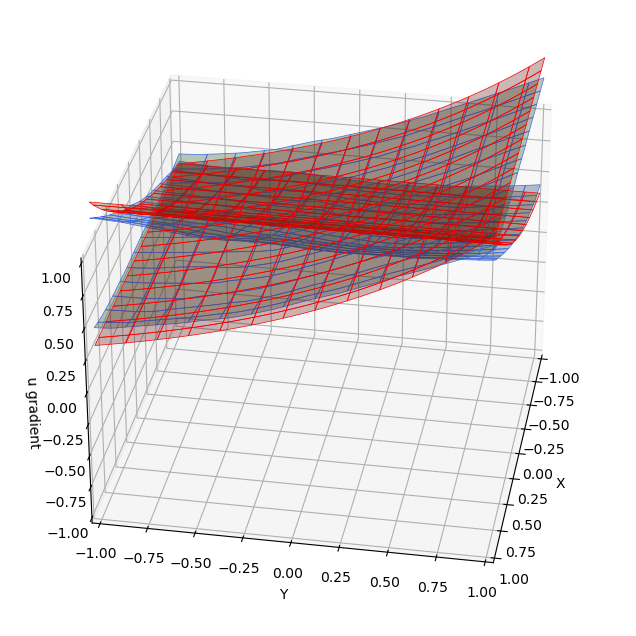

In [46]:
X1 = np.array(Z)[:, :, 1].reshape(101, 101)
X2 = np.sqrt(c)*np.exp(np.sqrt(c)*X)
Y1 = np.array(Z)[:, :, 2].reshape(101, 101)
Y2 = np.sqrt(c)*np.exp(np.sqrt(c)*Y)

import matplotlib.pyplot as plt
ax = plt.figure(figsize = (8, 8)).add_subplot(projection='3d')

# Plot the 3D surface
ax.plot_surface(X, Y, X1, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3, label = 'gradient of x')
ax.plot_surface(X, Y, X2, edgecolor='red', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
ax.plot_surface(X, Y, Y1, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3, label = 'gradient of y')
ax.plot_surface(X, Y, Y2, edgecolor='red', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)

ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(-1, 1),
       xlabel='X', ylabel='Y', zlabel='u gradient')

ax.view_init(30, 10)

#ax.set_box_aspect(None, zoom=0.85)
#ax.set_title("Fig4: WoSNN gradient approximation with evenly distributed start places for 2D Laplace", y=-0.01)
plt.show()
#plt.savefig('WoSNNeven2DlaplaceGradient.png', bbox_inches='tight')

(101, 101)


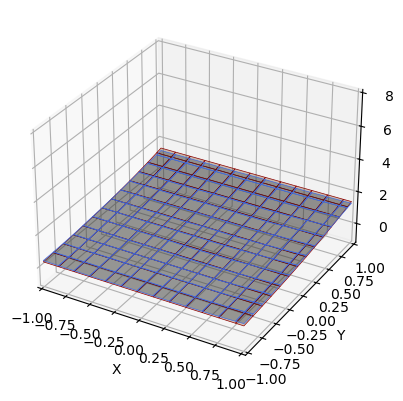

In [47]:
Y1 = np.array(Z)[:, :, 2].reshape(101, 101)
Y2 = np.sqrt(c)*np.exp(np.sqrt(c)*Y)
print(Y1.shape)

import matplotlib.pyplot as plt
ax = plt.figure().add_subplot(projection='3d')

# Plot the 3D surface
ax.plot_surface(X, Y, Y1, edgecolor='royalblue', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)
ax.plot_surface(X, Y, Y2, edgecolor='darkred', lw=0.5, rstride=8, cstride=8,
                alpha=0.3)

ax.set(xlim=(-1, 1), ylim=(-1, 1), zlim=(-1, 8),
       xlabel='X', ylabel='Y', zlabel='Y gradient')

plt.show()

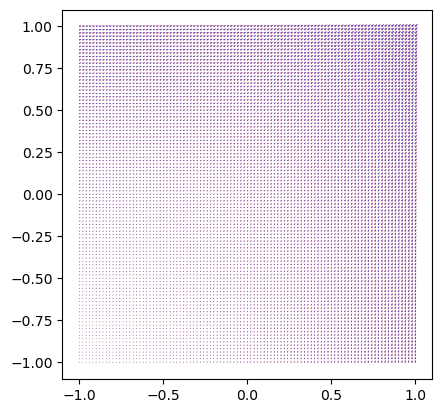

In [48]:
x = np.arange(-1, 1.02, 0.02)
y = np.arange(-1, 1.02, 0.02)
 
# Creating gradient
X, Y = np.meshgrid(x, y)
Z4 = np.exp(np.sqrt(c)*X)+np.exp(np.sqrt(c)*Y)
dx, dy = np.gradient(Z4)
Z3 = np.array(Z)[:, :, 1:3].reshape(-1, 2)

 
# Creating plot 
fig, ax = plt.subplots()
ax.quiver(X, Y, dx, dy, color = 'red')
ax.quiver(X, Y, Z3[:, 0].reshape(101, 101), Z3[:, 1].reshape(101, 101), color = 'royalblue')
 
#ax.xaxis.set_ticks([])
#ax.yaxis.set_ticks([])
ax.set_aspect('equal')
 
# show plot
plt.show()